In [1]:
from brian2 import *
from scipy import integrate
from scipy.integrate import odeint
from scipy.optimize import curve_fit

sys.path.append('../scripts_analysis')
# sys.path.append('../steps')
# sys.path.append('../../scripts')
from analysis import *
from peaks import *
from misc import *

from spike_tools import *

import matplotlib as mpl
from cycler import cycler

BrianLogger.suppress_hierarchy('brian2.groups.group.Group.resolve.resolution_conflict')
BrianLogger.suppress_hierarchy('brian2.codegen')

plt.style.use('dark_background')
mpl.rcParams['axes.prop_cycle'] = cycler(color=cpall)
#plt.rcParams.update(plt.rcParamsDefault)

resultPath = "../data/control/"

dirs = [a for a in getDirs(resultPath, sstr='nVDCC')]# if "bISI" in a]
dirs = np.array(dirs)
# for i,d in enumerate(dirs): print(i, d)

rep_des_path = "../model_mcell/representative_designs.txt"
with open(rep_des_path, 'r') as f:
    rep_designs = [a.strip() for a in f.readlines()]

rep_designs

['nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10',
 'nVDCC_3_dVAZ_100_nAZ_29_RRP_55_ISI_20_nAP_10',
 'nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10',
 'nVDCC_3_dVAZ_80_nAZ_35_RRP_30_ISI_20_nAP_10',
 'nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10',
 'nVDCC_4_dVAZ_120_nAZ_25_RRP_55_ISI_20_nAP_10',
 'nVDCC_4_dVAZ_120_nAZ_33_RRP_50_ISI_20_nAP_10',
 'nVDCC_4_dVAZ_80_nAZ_21_RRP_30_ISI_20_nAP_10',
 'nVDCC_5_dVAZ_100_nAZ_11_RRP_50_ISI_20_nAP_10',
 'nVDCC_5_dVAZ_120_nAZ_15_RRP_50_ISI_20_nAP_10',
 'nVDCC_5_dVAZ_120_nAZ_23_RRP_40_ISI_20_nAP_10',
 'nVDCC_5_dVAZ_120_nAZ_35_RRP_25_ISI_20_nAP_10',
 'nVDCC_5_dVAZ_220_nAZ_35_RRP_50_ISI_20_nAP_10',
 'nVDCC_5_dVAZ_80_nAZ_21_RRP_10_ISI_20_nAP_10',
 'nVDCC_5_dVAZ_80_nAZ_29_RRP_10_ISI_20_nAP_10',
 'nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10',
 'nVDCC_6_dVAZ_160_nAZ_19_RRP_55_ISI_20_nAP_10',
 'nVDCC_6_dVAZ_160_nAZ_35_RRP_25_ISI_20_nAP_10',
 'nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10',
 'nVDCC_6_dVAZ_80_nAZ_17_RRP_10_ISI_20_nAP_10',
 'nVDCC_7_dVAZ_100_nAZ_33_RR

In [2]:
def get_rate_from_data(resultath, d):
    resultDir = os.path.join(resultPath, d)

    simInfo = getSimInfo(d, skip=0)
    ISI, nAP, RRP = int(simInfo['ISI']), int(simInfo['nAP']), simInfo['RRP']

    inf = os.path.join(resultDir, 'vesData.dat')
    with open(inf, "rb") as infile:
        vesData = pk.load(infile)

    seeds = len(vesData[RRP])

    ## vesicle release times
    vTimes = np.sort(np.concatenate(vesData[RRP]))

    bindt = 0.0005 #sec
    bins = np.arange(0, (1.5 + nAP*ISI)/1000, bindt)
    n, bins = np.histogram(vTimes, bins)

    vrate = n/(seeds*bindt)
    vratet = np.array([a-bindt for a in bins[1:]])

    return vrate, vratet

###############################
# d = dirs[19]
# get_rate_from_data(resultPath, d)

In [3]:
def gen_MFB_vrel_rate(sptimes, params_MFB, nAP=10, ISI=20):
    ## MFB model equations (generates vesicle release rates)
    eqnMFB = '''
    #Facilitation dynamics
    du/dt = -u/tau_u : 1
    dx/dt = (1-x)/tau_x : 1
    dw/dt = -w/tau_w : 1

    dpCa/dt = (w - pCa)/tau_pCa : 1
    dbCa/dt = w/W + (Ca0 - bCa)/tau_bCa : 1
    drrp/dt = (-w + 1 - rrp)/tau_rrp : 1

    dsyncRel/dt = S*rrp*pCa*w - syncRel/tau_syncRel : 1
    dasyncRel/dt = A*rrp*bCa*w - asyncRel/tau_asyncRel : 1
    '''
    
    updates = '''
    u += U_SE * (1 - u)
    x -= u * x
    w += A_SE * u * x
    '''
    start_scope()

    nMFB = 1
    MFB = NeuronGroup(nMFB, eqnMFB, method='euler', namespace=params_MFB)
    MFB.bCa = params_MFB['Ca0']
    MFB.rrp = 1
    MFB.x = 1

    MFBinp = SpikeGeneratorGroup(1, [0]*nAP, sptimes)

    ### Synapses
    S_MFBinp_MFB = Synapses(MFBinp, MFB, on_pre=updates, namespace=params_MFB)
    S_MFBinp_MFB.connect(i=0, j=range(nMFB))

    stMMFB = StateMonitor(MFB, variables=True, record=True)
    #spMMFB = SpikeMonitor(MFB)
    spMMFBinp = SpikeMonitor(MFBinp)

    runt = nAP*ISI
    run(runt*ms)
    
    return stMMFB, spMMFBinp

In [4]:
d = rep_designs[43]
print('Directory: ', d)

simInfo = getSimInfo(d, skip=0)
ISI, nAP, RRP = int(simInfo['ISI']), int(simInfo['nAP']), simInfo['RRP']
runt = nAP*ISI
sptimes = np.sort([1.5 + na*ISI for na in range(nAP)])/1000*second

vrate, vratet = get_rate_from_data(resultPath, d)
cumul_vrate = integrate.cumulative_simpson(vrate, x=vratet*1000, initial=0)

Directory:  nVDCC_14_dVAZ_180_nAZ_9_RRP_25_ISI_20_nAP_10


In [5]:
params_MFB = dict(
    Ca0 = 0.1, 
    tau_pCa = 0.1*ms,
    tau_bCa = 80*ms, 
    tau_syncRel = 0.4*ms, 
    tau_asyncRel = 20*ms, 
    tau_rrp = 500*ms, 
    tau_u = 80*ms,
    tau_x = 10*ms,
    tau_w = 1*ms,
    w0 = 1,
    A_SE = 10,
    U_SE = 0.15,
    S = 450/ms,
    A = 8/ms,
    W = 1*ms
)
stMMFB, spMMFBinp = gen_MFB_vrel_rate(sptimes, params_MFB)
srate, asrate = stMMFB.syncRel[0], stMMFB.asyncRel[0]
cumul_rate = integrate.cumulative_simpson(srate + asrate, x=stMMFB.t/ms, initial=0)

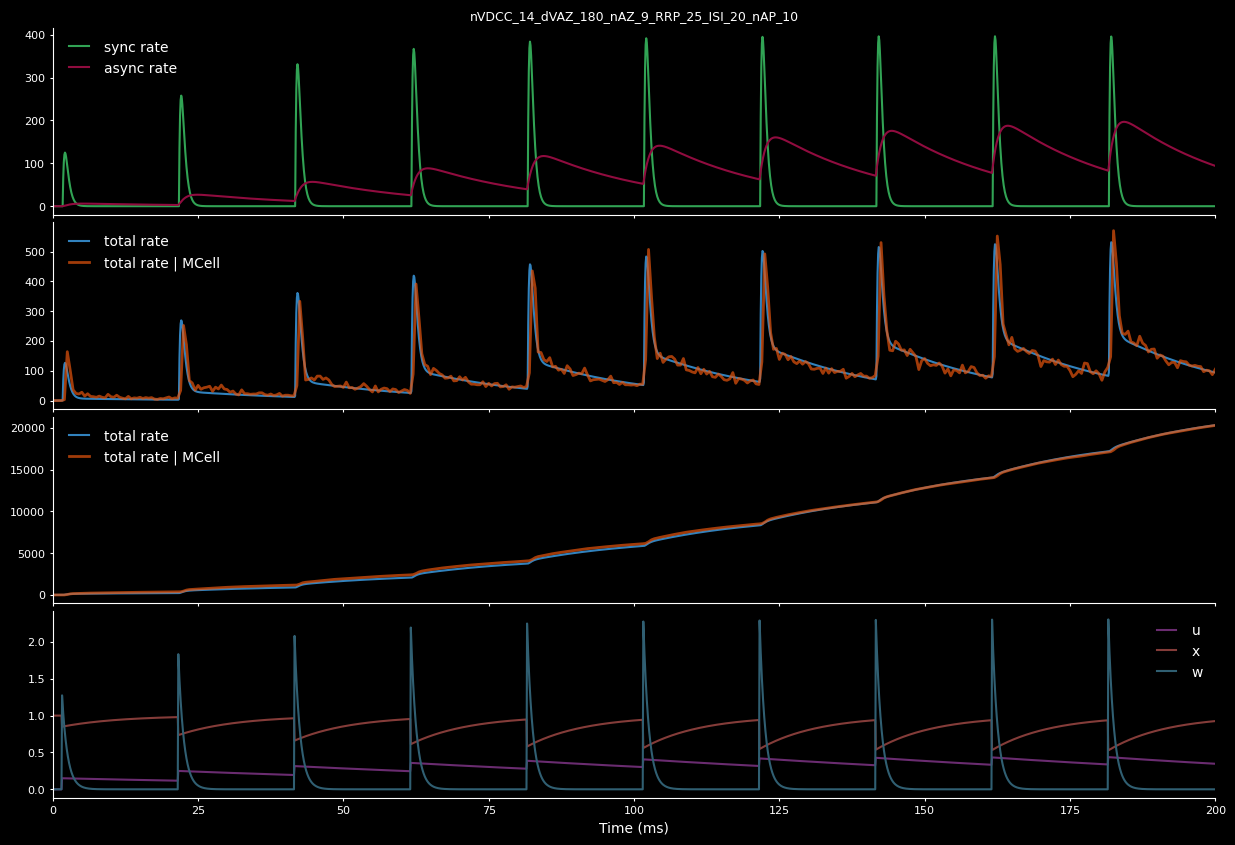

In [6]:
f, ax = plt.subplots(4, sharex=True, figsize=(15,10))
f.subplots_adjust(wspace=0., hspace=0.04)

ax[0].plot(stMMFB.t/ms, srate, color=cpdark[2], label='sync rate')
ax[0].plot(stMMFB.t/ms, asrate, color=cpdark[3], label='async rate')
ax[0].set_title(d, fontsize=9)

ax[1].plot(stMMFB.t/ms, srate + asrate, '-', color=cpdark[0], label='total rate')
ax[1].plot(vratet*1000, vrate, '-', color=cpdark[1], lw=2, alpha=0.7, label='total rate | MCell')

ax[2].plot(stMMFB.t/ms, cumul_rate, color=cpdark[0], label='total rate')
ax[2].plot(vratet*1000, cumul_vrate, color=cpdark[1], lw=2, alpha=0.7, label='total rate | MCell')

# ax[3].plot(stMMFB.t/ms, stMMFB.pCa[:1].T, color=cpdark[4], alpha=0.8, label='peak Ca')
# ax[3].plot(stMMFB.t/ms, stMMFB.bCa[:1].T, color=cpdark[5], alpha=0.8, label='base Ca')
# ax[3].plot(stMMFB.t/ms, stMMFB.rrp[0], color=cpdark[6], label='rrp')
ax[3].plot(stMMFB.t/ms, stMMFB.u[0], color=cpdark[7], label='u')
ax[3].plot(stMMFB.t/ms, stMMFB.x[0], color=cpdark[8], label='x')
ax[3].plot(stMMFB.t/ms, stMMFB.w[0], color=cpdark[9], label='w')

ax[-1].set_xlabel('Time (ms)')
for axis in ax.ravel():
    axis.set_xlim(0, runt)
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, labelsize=8)
    axis.legend(frameon=False, numpoints=2)#, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')
    # axis.set_xlim(0,5)
plt.show()

In [1537]:
design_params = {d: params_MFB}

try:
    ## Read from file
    with open('MFB_design_params.pkl', "rb") as infile:
        MFB_design_params = pk.load(infile)

except FileNotFoundError:
    MFB_design_params = {}

## Update and save
MFB_design_params.update(design_params)
with open('MFB_design_params.pkl', "wb") as outfile:
    pk.dump(MFB_design_params, outfile)

design_params#, MFB_design_params

{'nVDCC_14_dVAZ_180_nAZ_9_RRP_25_ISI_20_nAP_10': {'Ca0': 0.1,
  'tau_pCa': 100. * usecond,
  'tau_bCa': 80. * msecond,
  'tau_syncRel': 0.4 * msecond,
  'tau_asyncRel': 20. * msecond,
  'tau_rrp': 0.5 * second,
  'tau_u': 80. * msecond,
  'tau_x': 10. * msecond,
  'tau_w': 1. * msecond,
  'w0': 1,
  'A_SE': 10,
  'U_SE': 0.15,
  'S': 0.45 * Mhertz,
  'A': 8. * khertz,
  'W': 1. * msecond}}

In [1538]:
with open('MFB_design_params.pkl', "rb") as infile:
    MFB_design_params = pk.load(infile)

print(len(MFB_design_params)) 
for k1,k2 in zip(np.sort(list(MFB_design_params.keys())), np.sort(rep_designs[:len(MFB_design_params)])):
    print(f'{k1}\n{k2}\n')

44
nVDCC_10_dVAZ_180_nAZ_15_RRP_25_ISI_20_nAP_10
nVDCC_10_dVAZ_180_nAZ_15_RRP_25_ISI_20_nAP_10

nVDCC_11_dVAZ_160_nAZ_31_RRP_5_ISI_20_nAP_10
nVDCC_11_dVAZ_160_nAZ_31_RRP_5_ISI_20_nAP_10

nVDCC_11_dVAZ_180_nAZ_23_RRP_10_ISI_20_nAP_10
nVDCC_11_dVAZ_180_nAZ_23_RRP_10_ISI_20_nAP_10

nVDCC_11_dVAZ_220_nAZ_27_RRP_10_ISI_20_nAP_10
nVDCC_11_dVAZ_220_nAZ_27_RRP_10_ISI_20_nAP_10

nVDCC_11_dVAZ_220_nAZ_9_RRP_55_ISI_20_nAP_10
nVDCC_11_dVAZ_220_nAZ_9_RRP_55_ISI_20_nAP_10

nVDCC_12_dVAZ_160_nAZ_23_RRP_5_ISI_20_nAP_10
nVDCC_12_dVAZ_160_nAZ_23_RRP_5_ISI_20_nAP_10

nVDCC_12_dVAZ_160_nAZ_9_RRP_25_ISI_20_nAP_10
nVDCC_12_dVAZ_160_nAZ_9_RRP_25_ISI_20_nAP_10

nVDCC_13_dVAZ_140_nAZ_7_RRP_15_ISI_20_nAP_10
nVDCC_13_dVAZ_140_nAZ_7_RRP_15_ISI_20_nAP_10

nVDCC_13_dVAZ_200_nAZ_13_RRP_15_ISI_20_nAP_10
nVDCC_13_dVAZ_200_nAZ_13_RRP_15_ISI_20_nAP_10

nVDCC_14_dVAZ_180_nAZ_9_RRP_25_ISI_20_nAP_10
nVDCC_14_dVAZ_180_nAZ_9_RRP_25_ISI_20_nAP_10

nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_2

### Optimisation using curve_fit

In [ ]:
def fit_func(t, tau_u=40, tau_x=10, U_SE=0.05, S=1000, A=500, nAP=10, ISI=20):
    stMMFB, spMMFBinp = gen_MFB_vrel_rate(sptimes, tau_u=tau_u, tau_x=tau_x, U_SE=U_SE, S=S, A=A, nAP=nAP, ISI=ISI)
    return stMMFB.syncRel[0] + stMMFB.asyncRel[0]

data_t = vratet
data_y = vrate

_tau_u=40
_tau_x=10
_U_SE=0.05
_S=1000
_A=500
y = fit_func(data_t, _tau_u, _tau_x, _U_SE, _S, _A)
len(y), len(data_y), len(data_t)


In [ ]:
p0 = [_tau_u, _tau_x, _U_SE, _S, _A]
popt, cov = curve_fit(fit_func, data_t, data_y, p0=p0)
tau_u, tau_x, U_SE, S, A = popt

print(f"tau_u = {tau_u}, tau_x = {tau_x}, U_SE = {U_SE}, S = {S}, A = {A}")
# print(cov)

plt.plot(data_t, data_y, '.')
plt.plot(data_t, fit_func(data_t, tau_u, tau_x, U_SE, S, A), '-', label='numerical solution')
plt.plot(data_t, fit_func(data_t, _tau_u, _tau_x, _U_SE, _S, _A), 'r-', label='guess')
plt.legend()
plt.ylim(-10,110)
plt.show()

### bleh

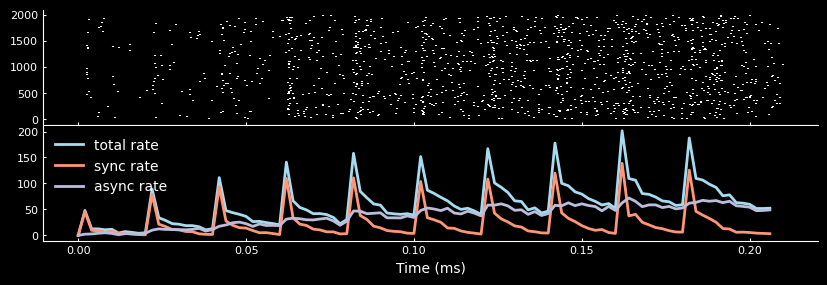

In [7]:
f, ax = plt.subplots(2, figsize=(10,3), sharex=True)
f.subplots_adjust(wspace=0.01, hspace=0.01)

ax[0].eventplot(vrel[:])

ax[1].plot(vratet, vrate, color=cplight[1], lw=2, label='total rate')
ax[1].plot(vratet, svrate, color=cplight[2], lw=2, label='sync rate')
ax[1].plot(vratet, asvrate, color=cplight[3], lw=2, label='async rate')
ax[1].legend(frameon=False)

ax[-1].set_xlabel('Time (ms)')
for axis in ax.ravel():
    #axis.set_xlim(0, runt)
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=8)
    
plt.show()

## Simulations Without Plasticity

In [ ]:
start_scope()
runt = 2000

### MFB without plasticity
Ca0 = 0.1
tau_Ca = 700*ms
tau_sync = 8*ms
tau_async = 150*ms

### MFB G without plasticity
on_preMFBwp = 'sync += 400; async += 10'

## MFB equation
eqnMFBwp = '''
dsync/dt = -sync/tau_sync : 1
dasync/dt = -async/tau_async : 1
'''
MFBwp = NeuronGroup(nMFB, eqnMFBwp, method='euler')

### Input spikes to MFB
corrTrains = genCorrSpikeTrains(0.75, rate=30, tspan=runt, n=nMFB)
indCorr = []
for i,e in enumerate(corrTrains):
    indCorr += np.full(len(e), i).tolist()

MFBinp = SpikeGeneratorGroup(nMFB, indices, np.concatenate(corrTrains)*ms)
#MFBinp = PoissonGroup(nMFB, 10*Hz)

### Synapses
## MFBinp ---> MFB
S_MFBinp_MFBwp = Synapses(MFBinp, MFBwp, on_pre=on_preMFBwp)
S_MFBinp_MFBwp.connect(i=0, j=range(nMFB))

stMMFBwp = StateMonitor(MFBwp, variables=True, record=True)
#spMMFB = SpikeMonitor(MFB)

run(runt*ms)

done!


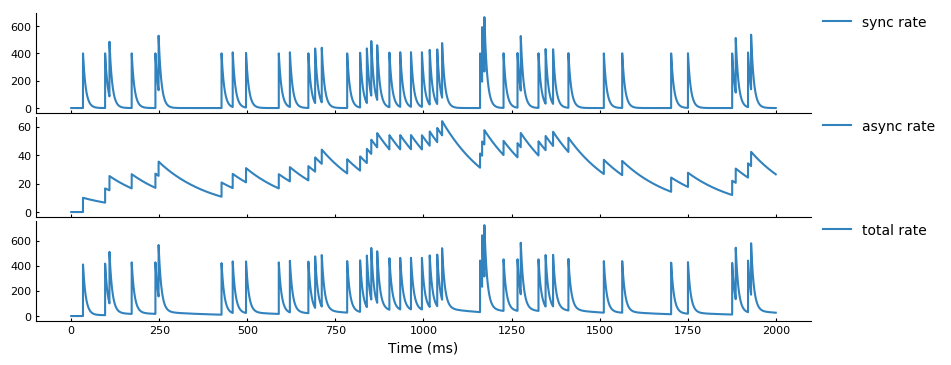

In [ ]:
f, ax = plt.subplots(3, sharex=True, figsize=(10,4))
f.subplots_adjust(wspace=0., hspace=0.04)

srate, asrate = stMMFBwp.sync[0], stMMFBwp.async[0]
ax[0].plot(stMMFBwp.t/ms, srate, color=cpdark[0], label='sync rate')
ax[0].legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

ax[1].plot(stMMFBwp.t/ms, asrate, color=cpdark[0], label='async rate')
ax[1].legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

ax[2].plot(stMMFBwp.t/ms, srate + asrate, color=cpdark[0], label='total rate')
ax[2].legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

#ax[3].plot(stMMFBwp.t/ms, stMMFBwp.Ca[:1].T, color=cpdark[2], alpha=0.8, label='Ca')
#ax[3].legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

ax[-1].set_xlabel('Time (ms)')
for axis in ax.ravel():
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=8)
plt.show()

## Simulations With Poisson Input

In [ ]:
start_scope()
runt = 2000

### MFB
Ca0 = 0.1
tau_Ca = 200*ms
tau_rCa = 500*ms
tau_sync = 8*ms
tau_async = 150*ms
tau_rrp = 1000*ms

on_preMFB = 'Ca += 0.035+0.01*(Ca-Ca0)/Ca0; sync += 50*(Ca-Ca0)/Ca0*rrp; async += 20*(Ca-Ca0)/Ca0*rrp; rCa += 0.2*(1-rCa)*Ca; rrp -= 0.04'


### MFB GC voltage equation
eqnMFB = '''
dCa/dt = (rCa - Ca)/tau_Ca : 1
dsync/dt = -sync/tau_sync : 1
dasync/dt = -async/tau_async : 1
drCa/dt = (Ca0 - rCa)/tau_rCa : 1
drrp/dt = (1 - rrp)/tau_rrp : 1
'''

nMFB = 2
MFB = NeuronGroup(nMFB, eqnMFB, method='euler')
MFB.Ca = Ca0
MFB.rCa = Ca0
MFB.rrp = 1

### Input spikes to MFB GC
corrTrains = genCorrSpikeTrains(0.75, rate=30, tspan=runt, n=nMFB)
indCorr = []
for i,e in enumerate(corrTrains):
    indCorr += np.full(len(e), i).tolist()

MFBinp = SpikeGeneratorGroup(nMFB, indices, np.concatenate(corrTrains)*ms)
#MFBinp = PoissonGroup(nMFB, 10*Hz)

### Synapses
## MFBinp ---> MFB
S_MFBinp_MFB = Synapses(MFBinp, MFB, on_pre=on_preMFB)
S_MFBinp_MFB.connect(i=0, j=range(nMFB))

stMMFB = StateMonitor(MFB, variables=True, record=True)
#spMMFB = SpikeMonitor(MFB)
run(runt*ms)
print('done!')

WARNING    Came across an abstract code block that may not be well-defined: the outcome may depend on the order of execution. You can ignore this warning if you are sure that the order of operations does not matter. 5 lines of abstract code, first line is: "Ca += 0.035 + (_lio_1 * (_lio_2 + Ca)) (in-place)"
 [brian2.codegen.generators.base]


done!


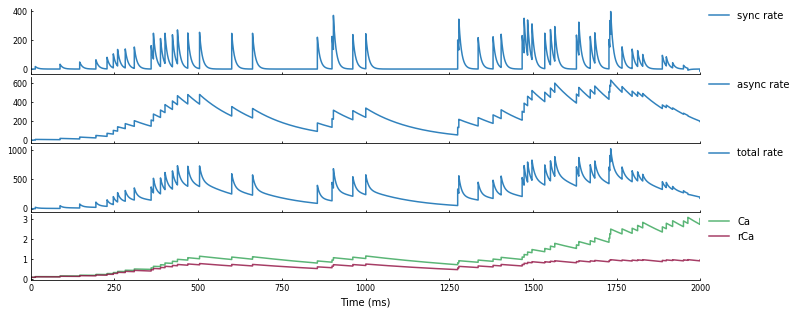

In [ ]:
f, ax = plt.subplots(4, sharex=True, figsize=(12,5))
f.subplots_adjust(wspace=0., hspace=0.04)

srate, asrate = stMMFB.sync[0], stMMFB.async[0]
ax[0].plot(stMMFB.t/ms, srate, color=cpdark[0], label='sync rate')
ax[0].legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

ax[1].plot(stMMFB.t/ms, asrate, color=cpdark[0], label='async rate')
ax[1].legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

ax[2].plot(stMMFB.t/ms, srate + asrate, color=cpdark[0], label='total rate')
ax[2].legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

ax[3].plot(stMMFB.t/ms, stMMFB.Ca[:1].T, color=cpdark[2], alpha=0.8, label='Ca')
ax[3].plot(stMMFB.t/ms, stMMFB.rCa[:1].T, color=cpdark[3], alpha=0.8, label='rCa')
ax[3].legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

ax[-1].set_xlabel('Time (ms)')
for axis in ax.ravel():
    axis.set_xlim(0,runt)
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=8)
plt.show()

## Generation of Correlated Poisson Spike Trains

In [ ]:
def genPoissonTrain(rate, tspan=1e3, dt=0.1):
    """
    freq: Hz; tspan: ms
    Assumption: no multiple event within 0.1 ms (default dt=0.1 ms)
    """
    rp = np.random.uniform(size=int(tspan/dt))
    train = np.array(np.where(np.less(rp, rate*dt*1e-3) == True))[0]*dt
    return train

def getSubTrains(train, p, n=1):
    """
    Generate n random subsets of original train 
    with probability p
    """
    rr = np.random.uniform(size=(n,train.shape[0]))
    subTrains = []
    for r in rr:
        temp = np.array(np.where(np.less(r, p) == True))[0]
        subTrains.append(train[temp].tolist())
    return subTrains

def genCorrSpikeTrains(corr, rate=1, n=1, tspan=1e3, dt=0.1):
    """
    corr: expected coefficient of correlation
    rate: Hz
    n: number of trains
    tspan: ms
    """
    poisTrain = genPoissonTrain(rate/corr, tspan=tspan, dt=dt)
    corrTrains = getSubTrains(poisTrain, corr, n=n)
    return corrTrains

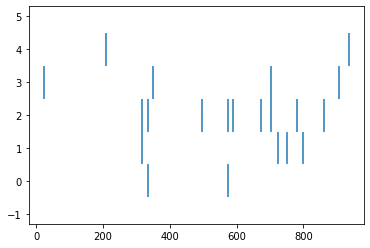

In [ ]:
corrTrains = genCorrSpikeTrains(0.2, 5, tspan=1e3, n=5)
#print(np.mean([len(c) for c in corrTrains]), np.std([len(c) for c in corrTrains]))
plt.eventplot(corrTrains)
plt.show()

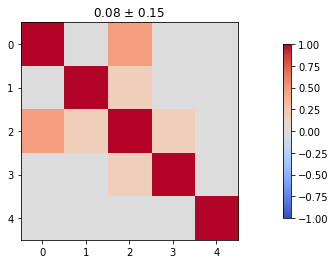

In [ ]:
f, ax = plt.subplots(1, figsize=(16,4), sharey=True)
f.subplots_adjust(wspace=0.05, hspace=0.01)

bsize = 10 # ms
dt = 0.1
bins = np.arange(0,1e3,dt)
binspt = np.zeros((len(corrTrains), len(bins)-1))

for i in range(len(corrTrains)):
    binspt[i] = np.histogram(corrTrains[i], bins=bins)[0]

corr = np.corrcoef(binspt)
offd = np.delete(corr.ravel(), np.s_[::corr.shape[1]+1])
ax.set_title(f"{np.mean(offd):0.2f} $\pm$ {np.std(offd):0.2f}")
hm = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

f.colorbar(hm, ax=ax, shrink=0.8);
plt.show()

(52,) 997.125


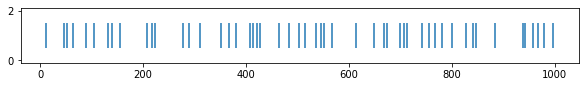

In [ ]:
def genPoissonTrain(rate, tspan=1e3, dt=0.1, refrac=5):
    """
    rate: Hz; tspan: ms
    Assumption: no multiple event within t=refrac ms
    """
    tt = rate*refrac/(1000-rate*refrac)
    arefrac = refrac*(1+tt)
    train = []
    rp = np.random.uniform(size=int(tspan*(1+tt)/dt))
    temp = -np.inf
    for i,r in enumerate(rp):
        if r<rate*dt*1e-3 and i*dt-temp > arefrac:
            #print(i, f'{i*dt:0.2f}, {temp:0.2f} {r:0.4f}')
            temp = i*dt
            train += [temp]
    return np.array(train)/(1+tt)

tr = genPoissonTrain(50)
f, ax = plt.subplots(1, figsize=(10,1))
ax.eventplot(tr)
print(tr.shape, tr[-1])
#tr

In [ ]:
tr = [genPoissonTrain(190).shape[0] for _ in range(200)]
np.mean(tr)

190.5

In [ ]:
beep = lambda x: os.system("echo -n '\a';sleep 0.2;" * x)
beep(30)

0